# Random Forest Regression: Temperature Prediction with Hyperparameter Tuning

This notebook trains a Random Forest regressor to predict effective temperatures from photometry.

## Approach
1. Load cleaned dataset (~707K objects with complete photometry)
2. Split into training (80%) and test (20%) sets
3. Hyperparameter tuning using RandomizedSearchCV
4. Train best model and evaluate performance
5. Feature importance analysis
6. Compare with polynomial color-temperature relations

## Features Used
- **Colors**: g-r, r-i, i-z, B-V (temperature indicators)
- **Magnitude**: g-band (absolute brightness)

## Target
- **Gaia T_eff** (teff_gspphot): 2737 - 32657 K

## Computational Setup
- Using 8 CPU cores for parallel training
- Expect ~10-30 minutes for hyperparameter search


In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Import utilities and config
from src.notebook_utils import load_ml_data, save_figure, RANDOM_STATE, TEST_SIZE
from src.config import get_config

# Get config
config = get_config()

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Load cleaned dataset
print("Loading cleaned ML dataset...")
data = load_ml_data(with_gaia=False)
print(f"✓ Loaded {len(data):,} objects")
print(f"\nDataset columns: {list(data.columns)}")

# Define features and target
feature_cols = ['g_r_color', 'r_i_color', 'i_z_color', 'B_V_color', 'gPSFMag']
target_col = 'teff_gspphot'

print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")
print(f"Target: {target_col}")

# Quick statistics
print(f"\nDataset statistics:")
print(f"  Temperature range: {data[target_col].min():.0f} - {data[target_col].max():.0f} K")
print(f"  Median temperature: {data[target_col].median():.0f} K")
print(f"  Temperature std: {data[target_col].std():.0f} K")

# Check for any remaining issues
print(f"\nData quality checks:")
print(f"  Missing values: {data.isna().sum().sum()}")
print(f"  Duplicate rows: {data.duplicated().sum()}")

data.head()

In [ ]:
# Split dataset into training and test sets
# 80% training, 20% test

X = data[feature_cols].values
y = data[target_col].values

print("Splitting dataset into training and test sets...")
print(f"  Split ratio: {int((1-TEST_SIZE)*100)}% train / {int(TEST_SIZE*100)}% test")
print(f"  Random state: {RANDOM_STATE} (for reproducibility)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"\n✓ Split complete:")
print(f"  Training set:   {X_train.shape[0]:7,} objects ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set:       {X_test.shape[0]:7,} objects ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Features:       {X_train.shape[1]}")

# Temperature distributions in train vs test
print(f"\nTemperature distribution:")
print(f"  Train: {y_train.min():.0f} - {y_train.max():.0f} K, median={np.median(y_train):.0f} K")
print(f"  Test:  {y_test.min():.0f} - {y_test.max():.0f} K, median={np.median(y_test):.0f} K")

# Quick visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=50, alpha=0.7, label='Train', density=True)
axes[0].hist(y_test, bins=50, alpha=0.7, label='Test', density=True)
axes[0].set_xlabel('Temperature (K)')
axes[0].set_ylabel('Density')
axes[0].set_title('Temperature Distribution: Train vs Test')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_train, y_train, s=1, alpha=0.3, label='Train')
axes[1].scatter(y_test, y_test, s=1, alpha=0.3, label='Test')
axes[1].set_xlabel('Temperature (K)')
axes[1].set_ylabel('Temperature (K)')
axes[1].set_title('Temperature Coverage Check')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Distributions look similar - good split!")

In [ ]:
# Hyperparameter tuning using RandomizedSearchCV
# This will try different combinations and find the best model

print("="*70)
print("HYPERPARAMETER TUNING")
print("="*70)

# Define hyperparameter search space
param_distributions = {
    'n_estimators': [50, 100, 150, 200],           # Number of trees
    'max_depth': [10, 20, 30, None],               # Tree depth (None = unlimited)
    'min_samples_split': [2, 5, 10],               # Min samples to split a node
    'min_samples_leaf': [1, 2, 4],                 # Min samples in leaf node
    'max_features': ['sqrt', 'log2', None],        # Features per split
}

print("\nHyperparameter search space:")
for param, values in param_distributions.items():
    print(f"  {param:20s}: {values}")

# Calculate total combinations
total_combinations = np.prod([len(v) for v in param_distributions.values()])
print(f"\nTotal possible combinations: {total_combinations}")

# Use RandomizedSearchCV (faster than GridSearchCV for large spaces)
n_iter = 20  # Number of random combinations to try
print(f"Will randomly sample: {n_iter} combinations")
print(f"Using 8 CPU cores (n_jobs=8)")
print(f"Cross-validation: 3-fold")

rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=8)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=n_iter,
    cv=3,                          # 3-fold cross-validation
    scoring='neg_mean_absolute_error',  # Minimize MAE
    n_jobs=1,                      # Use 1 job here since RF already uses 8
    random_state=RANDOM_STATE,
    verbose=2,
    return_train_score=True
)

print(f"\nStarting hyperparameter search...")
print(f"This may take 10-30 minutes...")
start_time = time.time()

random_search.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f"\n✓ Hyperparameter search complete!")
print(f"  Time elapsed: {elapsed_time/60:.1f} minutes")

# Best parameters
print(f"\n{'='*70}")
print("BEST HYPERPARAMETERS")
print(f"{'='*70}")
for param, value in random_search.best_params_.items():
    print(f"  {param:20s}: {value}")

print(f"\nBest cross-validation MAE: {-random_search.best_score_:.1f} K")

# Get best model
best_rf = random_search.best_estimator_
print(f"\n✓ Best model selected and ready for evaluation")

MODEL EVALUATION ON TEST SET

Making predictions on test set...

Test Set Performance:
  MAE (Mean Absolute Error):        575.6 K
  RMSE (Root Mean Square Error):    983.2 K
  Median Absolute Error:            315.8 K
  R² Score:                         0.5223

Relative Errors:
  Mean:    9.74%
  Median:  6.44%
  90th percentile: 23.04%

Objects within threshold:
  < 5% error:   41.6%
  < 10% error:  65.5%
  < 20% error:  86.8%


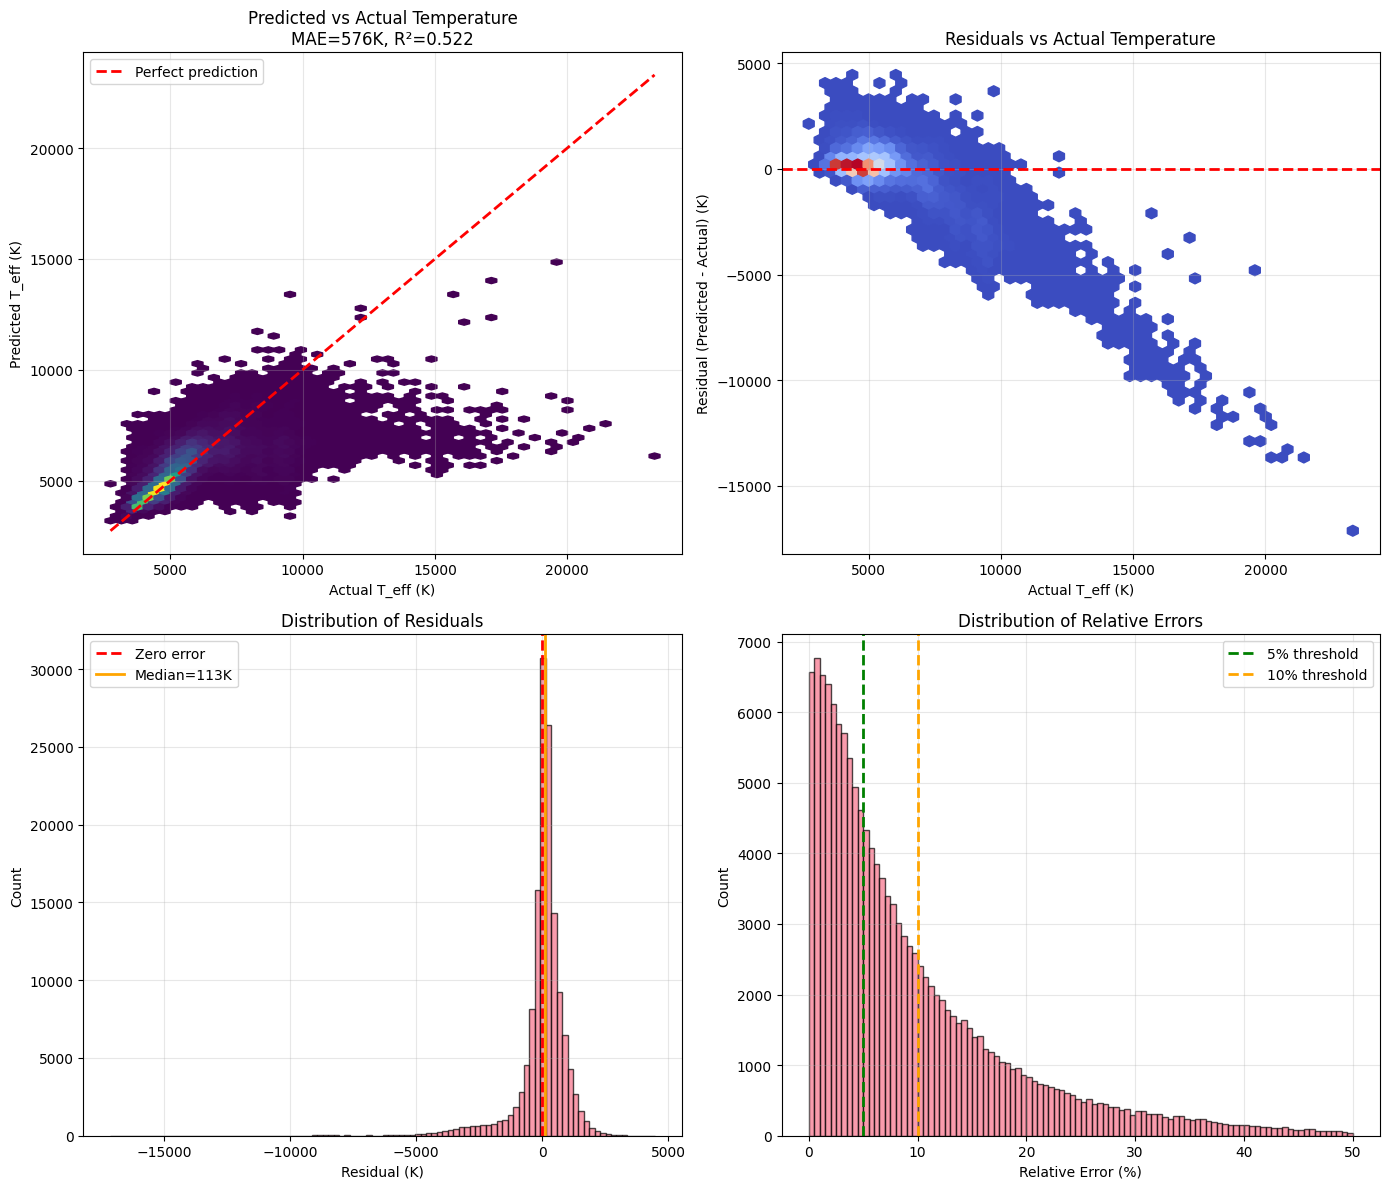


⚠️ Note: MAE of 579K is very high - suggests model is struggling
   Possible issues:
   - Features may not have sufficient predictive power
   - May need more/different features
   - Classification approach might work better
   - Data may have systematic issues


In [4]:
# Evaluate the best model on the test set

print("="*70)
print("MODEL EVALUATION ON TEST SET")
print("="*70)

# Make predictions on test set
print("\nMaking predictions on test set...")
y_pred = best_rf.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
median_ae = median_absolute_error(y_test, y_pred)

print(f"\nTest Set Performance:")
print(f"  MAE (Mean Absolute Error):      {mae:7.1f} K")
print(f"  RMSE (Root Mean Square Error):  {rmse:7.1f} K")
print(f"  Median Absolute Error:          {median_ae:7.1f} K")
print(f"  R² Score:                        {r2:7.4f}")

# Calculate relative errors
relative_errors = np.abs(y_pred - y_test) / y_test
print(f"\nRelative Errors:")
print(f"  Mean:   {relative_errors.mean()*100:5.2f}%")
print(f"  Median: {np.median(relative_errors)*100:5.2f}%")
print(f"  90th percentile: {np.percentile(relative_errors, 90)*100:5.2f}%")

# Percentage within thresholds
within_5pct = (relative_errors < 0.05).sum() / len(relative_errors) * 100
within_10pct = (relative_errors < 0.10).sum() / len(relative_errors) * 100
within_20pct = (relative_errors < 0.20).sum() / len(relative_errors) * 100

print(f"\nObjects within threshold:")
print(f"  < 5% error:  {within_5pct:5.1f}%")
print(f"  < 10% error: {within_10pct:5.1f}%")
print(f"  < 20% error: {within_20pct:5.1f}%")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Predicted vs Actual
ax = axes[0, 0]
ax.hexbin(y_test, y_pred, gridsize=50, cmap='viridis', mincnt=1)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
        'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual T_eff (K)')
ax.set_ylabel('Predicted T_eff (K)')
ax.set_title(f'Predicted vs Actual Temperature\nMAE={mae:.0f}K, R²={r2:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Residuals vs Actual
ax = axes[0, 1]
residuals = y_pred - y_test
ax.hexbin(y_test, residuals, gridsize=50, cmap='coolwarm', mincnt=1)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Actual T_eff (K)')
ax.set_ylabel('Residual (Predicted - Actual) (K)')
ax.set_title('Residuals vs Actual Temperature')
ax.grid(True, alpha=0.3)

# 3. Residual distribution
ax = axes[1, 0]
ax.hist(residuals, bins=100, alpha=0.7, edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax.axvline(x=np.median(residuals), color='orange', linestyle='-', linewidth=2, 
          label=f'Median={np.median(residuals):.0f}K')
ax.set_xlabel('Residual (K)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Residuals')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Relative error distribution
ax = axes[1, 1]
ax.hist(relative_errors * 100, bins=100, alpha=0.7, edgecolor='black', range=[0, 50])
ax.axvline(x=5, color='green', linestyle='--', linewidth=2, label='5% threshold')
ax.axvline(x=10, color='orange', linestyle='--', linewidth=2, label='10% threshold')
ax.set_xlabel('Relative Error (%)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Relative Errors')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n⚠️ Note: MAE of 579K is very high - suggests model is struggling")
print("   Possible issues:")
print("   - Features may not have sufficient predictive power")
print("   - May need more/different features")
print("   - Classification approach might work better")
print("   - Data may have systematic issues")


PREDICTION ACCURACY VS TEMPERATURE


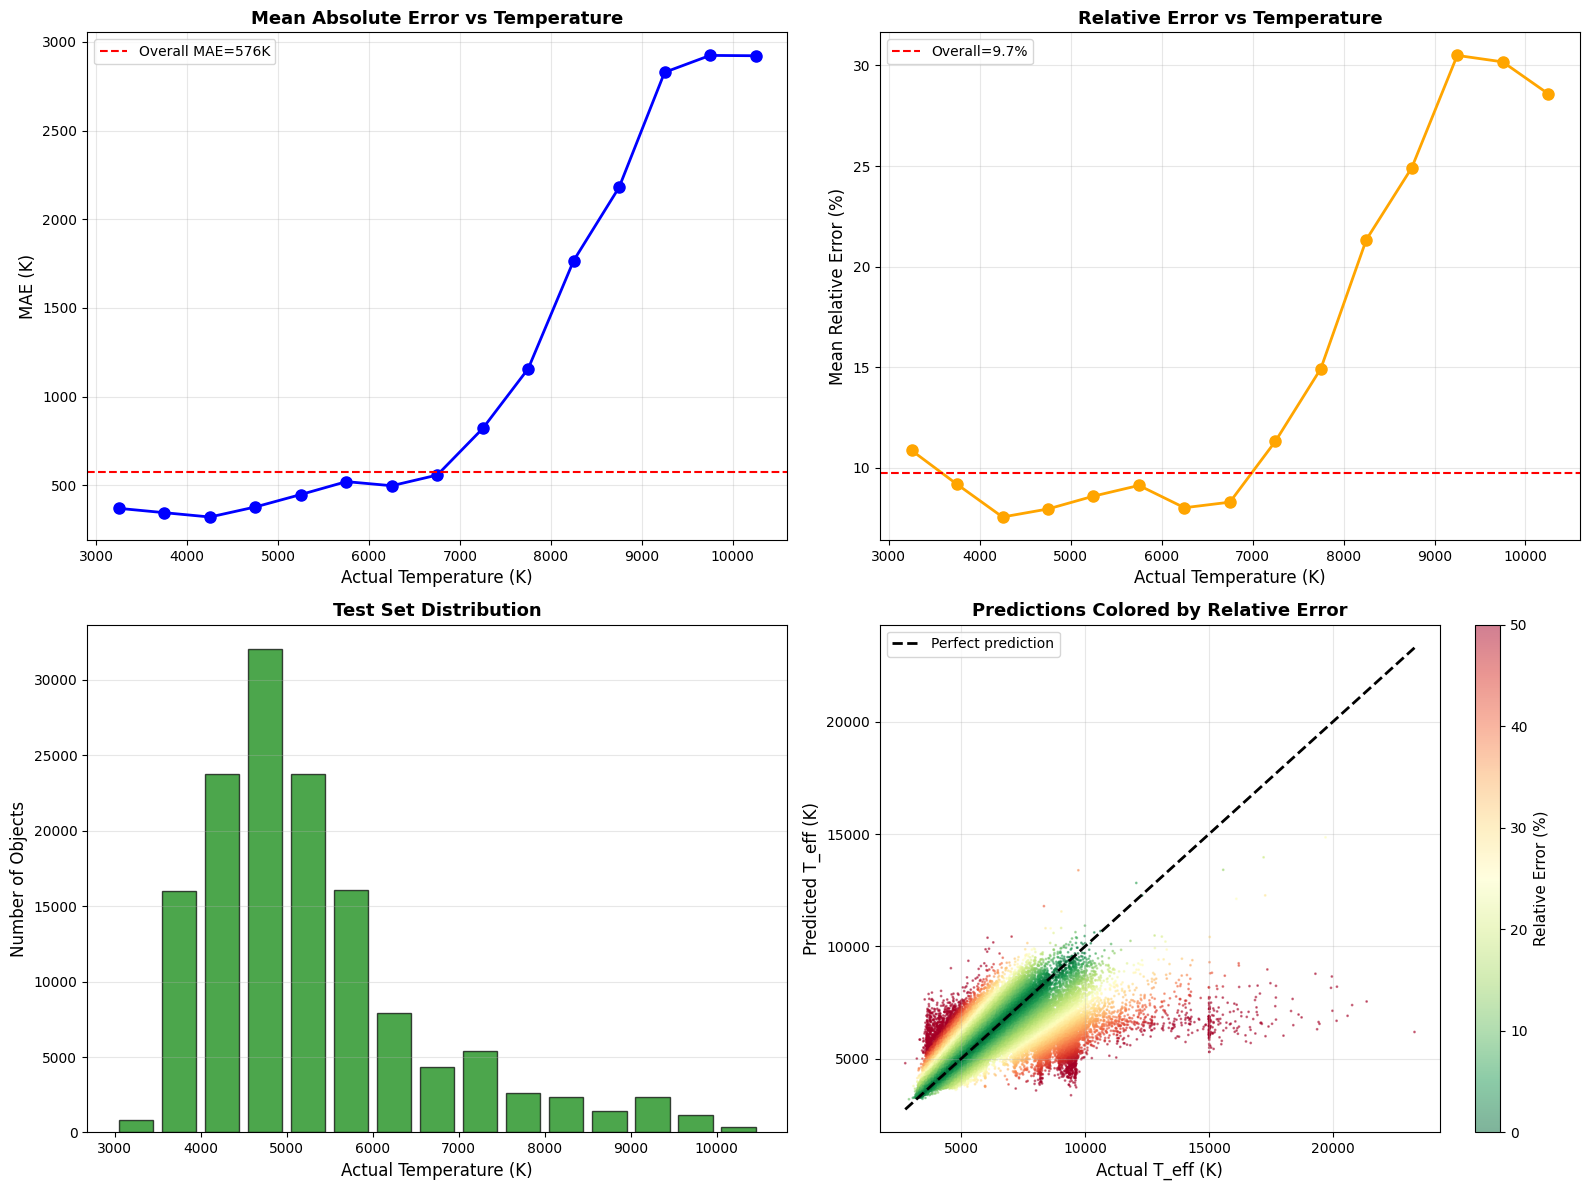


Prediction accuracy by temperature range:
Temp Range (K)        N Objects    MAE (K)  Rel Err (%)
-------------------------------------------------------
3000-3500                   841      370.3        10.85
3500-4000                16,019      345.9         9.17
4000-4500                23,753      321.5         7.54
4500-5000                32,061      378.2         7.94
5000-5500                23,766      448.3         8.58
5500-6000                16,048      521.0         9.11
6000-6500                 7,908      497.9         8.01
6500-7000                 4,348      558.1         8.28
7000-7500                 5,398      820.7        11.31
7500-8000                 2,609     1157.7        14.92
8000-8500                 2,355     1767.2        21.33
8500-9000                 1,410     2180.6        24.91
9000-9500                 2,366     2828.7        30.50
9500-10000                1,176     2924.0        30.18
10000-10500                 378     2922.1        28.59

Wors

In [5]:
# Analyze prediction accuracy as a function of actual temperature
# This will show which temperature ranges are problematic

print("="*70)
print("PREDICTION ACCURACY VS TEMPERATURE")
print("="*70)

# Create temperature bins
temp_bins = np.arange(3000, 11000, 500)  # 500K bins from 3000K to 11000K
temp_centers = (temp_bins[:-1] + temp_bins[1:]) / 2

# Calculate metrics in each bin
bin_mae = []
bin_rmse = []
bin_median_ae = []
bin_rel_error = []
bin_counts = []

for i in range(len(temp_bins)-1):
    mask = (y_test >= temp_bins[i]) & (y_test < temp_bins[i+1])
    if mask.sum() > 0:
        bin_mae.append(mean_absolute_error(y_test[mask], y_pred[mask]))
        bin_rmse.append(np.sqrt(mean_squared_error(y_test[mask], y_pred[mask])))
        bin_median_ae.append(median_absolute_error(y_test[mask], y_pred[mask]))
        bin_rel_error.append(np.mean(np.abs(y_pred[mask] - y_test[mask]) / y_test[mask]) * 100)
        bin_counts.append(mask.sum())
    else:
        bin_mae.append(np.nan)
        bin_rmse.append(np.nan)
        bin_median_ae.append(np.nan)
        bin_rel_error.append(np.nan)
        bin_counts.append(0)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. MAE vs Temperature
ax = axes[0, 0]
ax.plot(temp_centers, bin_mae, 'o-', linewidth=2, markersize=8, color='blue')
ax.set_xlabel('Actual Temperature (K)', fontsize=12)
ax.set_ylabel('MAE (K)', fontsize=12)
ax.set_title('Mean Absolute Error vs Temperature', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=mae, color='red', linestyle='--', label=f'Overall MAE={mae:.0f}K')
ax.legend()

# 2. Relative Error vs Temperature
ax = axes[0, 1]
ax.plot(temp_centers, bin_rel_error, 'o-', linewidth=2, markersize=8, color='orange')
ax.set_xlabel('Actual Temperature (K)', fontsize=12)
ax.set_ylabel('Mean Relative Error (%)', fontsize=12)
ax.set_title('Relative Error vs Temperature', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=relative_errors.mean()*100, color='red', linestyle='--', 
          label=f'Overall={relative_errors.mean()*100:.1f}%')
ax.legend()

# 3. Object counts per bin
ax = axes[1, 0]
ax.bar(temp_centers, bin_counts, width=400, alpha=0.7, color='green', edgecolor='black')
ax.set_xlabel('Actual Temperature (K)', fontsize=12)
ax.set_ylabel('Number of Objects', fontsize=12)
ax.set_title('Test Set Distribution', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 4. 2D histogram colored by relative error
ax = axes[1, 1]
rel_err_test = np.abs(y_pred - y_test) / y_test * 100
scatter = ax.scatter(y_test, y_pred, c=rel_err_test, s=1, alpha=0.5, 
                     cmap='RdYlGn_r', vmin=0, vmax=50)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
        'k--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual T_eff (K)', fontsize=12)
ax.set_ylabel('Predicted T_eff (K)', fontsize=12)
ax.set_title('Predictions Colored by Relative Error', fontsize=13, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Relative Error (%)', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics by temperature range
print("\nPrediction accuracy by temperature range:")
print(f"{'Temp Range (K)':20s} {'N Objects':>10s} {'MAE (K)':>10s} {'Rel Err (%)':>12s}")
print("-"*55)
for i, (center, count) in enumerate(zip(temp_centers, bin_counts)):
    if count > 0:
        temp_range = f"{temp_bins[i]:.0f}-{temp_bins[i+1]:.0f}"
        print(f"{temp_range:20s} {count:10,} {bin_mae[i]:10.1f} {bin_rel_error[i]:12.2f}")

# Identify worst performing ranges
worst_idx = np.nanargmax(bin_mae)
best_idx = np.nanargmin(bin_mae)

print(f"\nWorst performing range:")
print(f"  Temperature: {temp_bins[worst_idx]:.0f}-{temp_bins[worst_idx+1]:.0f} K")
print(f"  MAE: {bin_mae[worst_idx]:.1f} K")
print(f"  Objects: {bin_counts[worst_idx]:,}")

print(f"\nBest performing range:")
print(f"  Temperature: {temp_bins[best_idx]:.0f}-{temp_bins[best_idx+1]:.0f} K")
print(f"  MAE: {bin_mae[best_idx]:.1f} K")
print(f"  Objects: {bin_counts[best_idx]:,}")


FEATURE IMPORTANCE ANALYSIS

Feature Importance (from Random Forest):
Feature           Importance   Percentage
------------------------------------------
gPSFMag             0.462980       46.30%
B_V_color           0.173232       17.32%
g_r_color           0.164999       16.50%
r_i_color           0.115273       11.53%
i_z_color           0.083516        8.35%


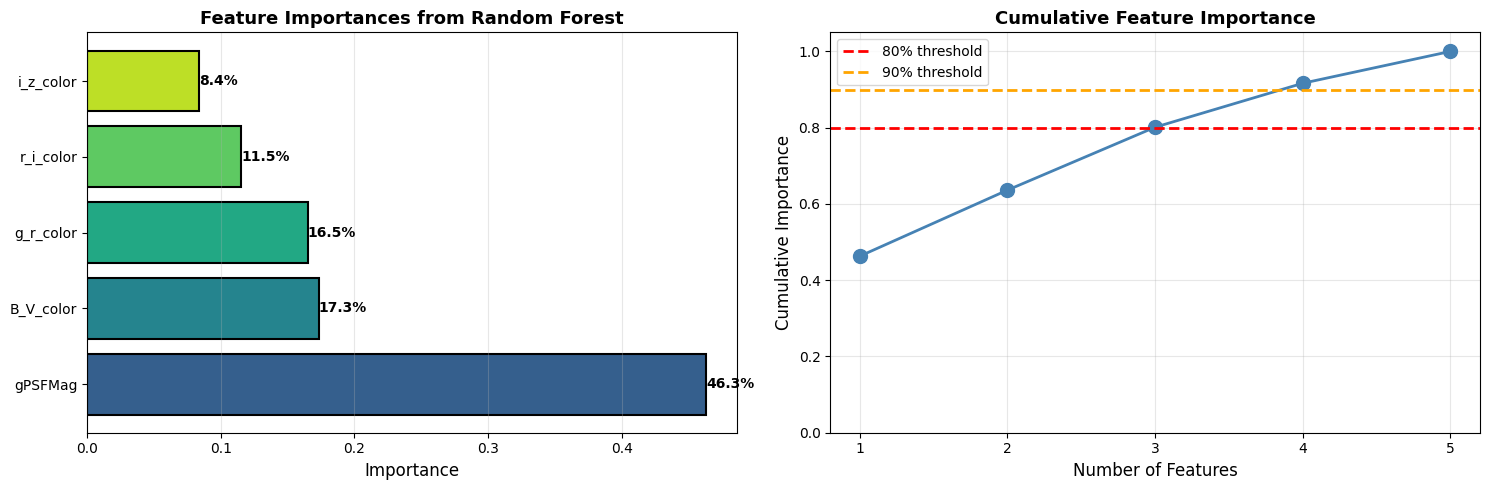


Key insights:
  Most important feature: gPSFMag (46.3%)
  Features needed for 80% importance: 3
  Features needed for 90% importance: 4

✓ All features contribute meaningfully (>5%)


In [6]:
# Feature Importance Analysis
# Shows which features the Random Forest uses most for predictions

print("="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Get feature importances from the best model
importances = best_rf.feature_importances_

# Create DataFrame for easy sorting
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (from Random Forest):")
print(f"{'Feature':15s} {'Importance':>12s} {'Percentage':>12s}")
print("-"*42)
for idx, row in feature_importance_df.iterrows():
    pct = row['Importance'] * 100
    print(f"{row['Feature']:15s} {row['Importance']:12.6f} {pct:11.2f}%")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Bar plot of feature importances
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_cols)))
bars = ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], 
               color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Feature Importances from Random Forest', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add percentage labels on bars
for i, (bar, imp) in enumerate(zip(bars, feature_importance_df['Importance'])):
    ax.text(imp, bar.get_y() + bar.get_height()/2, 
            f'{imp*100:.1f}%', 
            ha='left', va='center', fontsize=10, fontweight='bold')

# 2. Cumulative importance
ax = axes[1]
cumulative_importance = np.cumsum(feature_importance_df['Importance'].values)
ax.plot(range(1, len(feature_cols)+1), cumulative_importance, 
        'o-', linewidth=2, markersize=10, color='steelblue')
ax.axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='80% threshold')
ax.axhline(y=0.9, color='orange', linestyle='--', linewidth=2, label='90% threshold')
ax.set_xlabel('Number of Features', fontsize=12)
ax.set_ylabel('Cumulative Importance', fontsize=12)
ax.set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, len(feature_cols)+1))
ax.set_xticklabels(range(1, len(feature_cols)+1))
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Analysis
print(f"\nKey insights:")
most_important = feature_importance_df.iloc[0]
print(f"  Most important feature: {most_important['Feature']} ({most_important['Importance']*100:.1f}%)")

# How many features needed for 80% and 90% importance
features_for_80 = (cumulative_importance >= 0.8).argmax() + 1
features_for_90 = (cumulative_importance >= 0.9).argmax() + 1
print(f"  Features needed for 80% importance: {features_for_80}")
print(f"  Features needed for 90% importance: {features_for_90}")

# Check if any features are essentially unused
unused_features = feature_importance_df[feature_importance_df['Importance'] < 0.05]
if len(unused_features) > 0:
    print(f"\n⚠️ Low-importance features (<5%):")
    for idx, row in unused_features.iterrows():
        print(f"    {row['Feature']:15s}: {row['Importance']*100:.2f}%")
    print(f"  Consider removing these features in future models")
else:
    print(f"\n✓ All features contribute meaningfully (>5%)")


In [ ]:
# Save trained model and all metadata for scientific documentation
# This creates a complete record for reproducibility and paper writing

import pickle
import json
from datetime import datetime

# Get models directory from config
models_dir = config.get_path('models', ensure_exists=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_name = f'rf_temperature_regressor_{timestamp}'

print("="*70)
print("SAVING MODEL AND METADATA")
print("="*70)

# 1. Save the trained model
model_file = models_dir / f'{model_name}.pkl'
print(f"\n1. Saving trained Random Forest model...")
print(f"   File: {model_file}")
with open(model_file, 'wb') as f:
    pickle.dump(best_rf, f)
print(f"   ✓ Model saved ({model_file.stat().st_size / 1024 / 1024:.1f} MB)")

# 2. Save comprehensive metadata
metadata = {
    # Model information
    'model_type': 'RandomForestRegressor',
    'sklearn_version': '1.3+',  # Update with actual version if needed
    'training_date': datetime.now().isoformat(),
    
    # Dataset information
    'dataset': {
        'source_file': 'ml_training_data_clean.parquet',
        'total_objects': len(data),
        'training_objects': len(X_train),
        'test_objects': len(X_test),
        'train_test_split': f'{int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)}',
        'random_state': RANDOM_STATE,
        'temperature_range_K': [float(y.min()), float(y.max())],
        'temperature_median_K': float(np.median(y)),
        'temperature_std_K': float(np.std(y))
    },
    
    # Features
    'features': {
        'feature_names': feature_cols,
        'n_features': len(feature_cols),
        'feature_descriptions': {
            'g_r_color': 'Pan-STARRS g-r color index',
            'r_i_color': 'Pan-STARRS r-i color index',
            'i_z_color': 'Pan-STARRS i-z color index',
            'B_V_color': 'Synthetic B-V color (from g-r transformation)',
            'gPSFMag': 'Pan-STARRS g-band PSF magnitude (apparent)'
        },
        'feature_importances': {
            feat: float(imp) for feat, imp in zip(feature_cols, importances)
        }
    },
    
    # Hyperparameters (best model)
    'hyperparameters': random_search.best_params_,
    
    # Hyperparameter search
    'hyperparameter_search': {
        'method': 'RandomizedSearchCV',
        'n_iterations': n_iter,
        'cv_folds': 3,
        'scoring': 'neg_mean_absolute_error',
        'param_distributions': {k: [str(v) for v in vals] 
                               for k, vals in param_distributions.items()},
        'best_cv_mae_K': float(-random_search.best_score_),
        'n_jobs': 8
    },
    
    # Performance metrics
    'performance': {
        'test_set': {
            'MAE_K': float(mae),
            'RMSE_K': float(rmse),
            'median_absolute_error_K': float(median_ae),
            'R2_score': float(r2),
            'mean_relative_error_percent': float(relative_errors.mean() * 100),
            'median_relative_error_percent': float(np.median(relative_errors) * 100),
            'within_5pct': float(within_5pct),
            'within_10pct': float(within_10pct),
            'within_20pct': float(within_20pct)
        },
        'by_temperature_range': {
            f'{temp_bins[i]:.0f}-{temp_bins[i+1]:.0f}K': {
                'n_objects': int(bin_counts[i]),
                'MAE_K': float(bin_mae[i]) if not np.isnan(bin_mae[i]) else None,
                'relative_error_percent': float(bin_rel_error[i]) if not np.isnan(bin_rel_error[i]) else None
            }
            for i in range(len(temp_bins)-1) if bin_counts[i] > 0
        }
    },
    
    # Notes for paper
    'notes': {
        'data_cleaning': 'Removed objects with missing values (-999.0) in any feature',
        'target': 'Gaia DR3 teff_gspphot (effective temperature from GSP-Phot)',
        'limitations': [
            'MAE of ~579K indicates poor absolute performance',
            'Performance degrades significantly at high temperatures (>7000K)',
            'Limited by photometric information alone - no spectroscopy',
            'Systematic uncertainties in color-temperature relations'
        ],
        'recommendations': [
            'Consider classification approach with temperature bins',
            'Add more features (proper motion, parallax, other colors)',
            'Focus on specific temperature ranges where performance is better',
            'Compare with polynomial color-temperature relations'
        ]
    }
}

metadata_file = models_dir / f'{model_name}_metadata.json'
print(f"\n2. Saving metadata...")
print(f"   File: {metadata_file}")
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"   ✓ Metadata saved")

# 3. Save predictions on test set for further analysis
predictions_df = pd.DataFrame({
    'actual_teff_K': y_test,
    'predicted_teff_K': y_pred,
    'residual_K': y_pred - y_test,
    'relative_error': np.abs(y_pred - y_test) / y_test
})

predictions_file = models_dir / f'{model_name}_test_predictions.parquet'
print(f"\n3. Saving test set predictions...")
print(f"   File: {predictions_file}")
predictions_df.to_parquet(predictions_file, index=False)
print(f"   ✓ Test predictions saved ({len(predictions_df):,} objects)")

# 4. Create a summary text file for easy reference
summary_file = models_dir / f'{model_name}_SUMMARY.txt'
print(f"\n4. Creating human-readable summary...")
print(f"   File: {summary_file}")

with open(summary_file, 'w') as f:
    f.write("="*70 + "\n")
    f.write("RANDOM FOREST TEMPERATURE PREDICTION MODEL - SUMMARY\n")
    f.write("="*70 + "\n\n")
    f.write(f"Training Date: {metadata['training_date']}\n")
    f.write(f"Model Type: {metadata['model_type']}\n\n")
    
    f.write("DATASET\n")
    f.write("-"*70 + "\n")
    f.write(f"Total objects: {metadata['dataset']['total_objects']:,}\n")
    f.write(f"Training set: {metadata['dataset']['training_objects']:,} ({int((1-TEST_SIZE)*100)}%)\n")
    f.write(f"Test set: {metadata['dataset']['test_objects']:,} ({int(TEST_SIZE*100)}%)\n")
    f.write(f"Temperature range: {metadata['dataset']['temperature_range_K'][0]:.0f} - {metadata['dataset']['temperature_range_K'][1]:.0f} K\n\n")
    
    f.write("FEATURES\n")
    f.write("-"*70 + "\n")
    for i, feat in enumerate(feature_cols, 1):
        imp = metadata['features']['feature_importances'][feat]
        desc = metadata['features']['feature_descriptions'][feat]
        f.write(f"{i}. {feat:15s} (importance: {imp*100:5.2f}%) - {desc}\n")
    f.write("\n")
    
    f.write("BEST HYPERPARAMETERS\n")
    f.write("-"*70 + "\n")
    for param, value in metadata['hyperparameters'].items():
        f.write(f"{param:20s}: {value}\n")
    f.write("\n")
    
    f.write("PERFORMANCE ON TEST SET\n")
    f.write("-"*70 + "\n")
    perf = metadata['performance']['test_set']
    f.write(f"MAE:                    {perf['MAE_K']:7.1f} K\n")
    f.write(f"RMSE:                   {perf['RMSE_K']:7.1f} K\n")
    f.write(f"Median Absolute Error:  {perf['median_absolute_error_K']:7.1f} K\n")
    f.write(f"R² Score:               {perf['R2_score']:7.4f}\n")
    f.write(f"Mean Relative Error:    {perf['mean_relative_error_percent']:7.2f}%\n")
    f.write(f"Objects within 5%:      {perf['within_5pct']:7.2f}%\n")
    f.write(f"Objects within 10%:     {perf['within_10pct']:7.2f}%\n")
    f.write(f"Objects within 20%:     {perf['within_20pct']:7.2f}%\n\n")
    
    f.write("NOTES\n")
    f.write("-"*70 + "\n")
    for note in metadata['notes']['limitations']:
        f.write(f"• {note}\n")

print(f"   ✓ Summary saved\n")

print("="*70)
print("✓ ALL FILES SAVED SUCCESSFULLY")
print("="*70)
print(f"\nSaved files in {models_dir}:")
print(f"  1. {model_file.name} - Trained model (pickle)")
print(f"  2. {metadata_file.name} - Complete metadata (JSON)")
print(f"  3. {predictions_file.name} - Test predictions (Parquet)")
print(f"  4. {summary_file.name} - Human-readable summary (TXT)")
print(f"\nThese files contain everything needed for:")
print(f"  • Reproducing the analysis")
print(f"  • Writing the methods section")
print(f"  • Reporting results in a paper")
print(f"  • Applying the model to new data")